# Newton-Raphson Method
> **Numerical Methods for Engineering** | Module 01 - Root Finding | `02_Newton_Raphson.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/01-Root-Finding/02_Newton_Raphson.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- Derive the Newton-Raphson update formula from a **first-order Taylor expansion**.
- Prove why the method achieves **quadratic (second-order) convergence** near a simple root.
- Implement the algorithm in Python with analytic and finite-difference derivatives.
- Apply the method to problems in **general mathematics**, **chemistry**, and **telecommunications**.
- Identify pathological cases and apply safeguards against divergence.
- Quantitatively compare Newton-Raphson with Bisection in terms of iteration count.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, erfinv
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (11, 5), 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.35, 'lines.linewidth': 2,
})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 Derivation from Taylor's Theorem

Given a smooth $f$ and a current approximation $x_n$, expand $f$ around $x_n$:

$$f(x) = f(x_n) + f'(x_n)(x - x_n) + \frac{f''(x_n)}{2!}(x-x_n)^2 + \cdots$$

**Key idea:** truncate after the *linear* term and set the approximation to zero to get $x_{n+1}$:

$$0 \approx f(x_n) + f'(x_n)(x_{n+1} - x_n)$$

Solving for $x_{n+1}$:

$$\boxed{x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}, \quad f'(x_n) \neq 0}$$

**Geometric interpretation:** $x_{n+1}$ is the $x$-intercept of the **tangent line** to $f$ at $x_n$.

---

### 1.2 Convergence Analysis

**Theorem:** If $f$ has a simple root $r$ (i.e. $f(r)=0$, $f'(r)\neq0$) and $f''$ is continuous
near $r$, then Newton-Raphson converges **quadratically**:

$$|e_{n+1}| \leq \frac{M}{2m}\,|e_n|^2, \qquad e_n = x_n - r$$

where $M = \max|f''|$ and $m = \min|f'|$ on an interval around $r$.

**Proof:** Taylor-expand $f(r)=0$ around $x_n$:

$$0 = f(x_n) + f'(x_n)(r - x_n) + \frac{f''(\xi)}{2}(r - x_n)^2$$

Dividing by $f'(x_n)$ and rearranging:

$$\underbrace{x_{n+1} - r}_{e_{n+1}} = \underbrace{x_n - \frac{f(x_n)}{f'(x_n)}}_{x_{n+1}} - r
= -\frac{f''(\xi)}{2f'(x_n)}\,(x_n - r)^2$$

So:

$$|e_{n+1}| = \frac{|f''(\xi)|}{2|f'(x_n)|}\,|e_n|^2 \leq \frac{M}{2m}\,|e_n|^2 \qquad \square$$

> **Practical consequence:** once close to the root, the number of correct **decimal digits doubles**
> each iteration.

---

### 1.3 Stopping Criteria

| Criterion | Formula | Notes |
|-----------|---------|-------|
| Relative step | $\|x_{n+1}-x_n\|/\|x_{n+1}\| < \varepsilon_r$ | General-purpose |
| Function value | $\|f(x_{n+1})\| < \delta$ | When $f$ is cheap to evaluate |
| Combined | Both above | Most robust |

---

### 1.4 Pseudocode

```
INPUT:  f, f', x0, tol, max_iter

x <- x0
FOR i = 1 TO max_iter:
    IF |f'(x)| < tiny:
        STOP  -- derivative near zero
    x_new <- x - f(x) / f'(x)
    IF |x_new - x| / max(|x_new|, 1) < tol:
        RETURN x_new
    x <- x_new
END FOR
RETURN x
```

---

### 1.5 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| **Quadratic convergence** - very fast near a root | Requires $f'$ (analytic or numerical) |
| Typically far fewer iterations than Bisection | No guaranteed convergence from arbitrary $x_0$ |
| Extends to systems via Newton-Krylov / Newton-Raphson-Seidel | Fails if $f'(x_n) = 0$ at any iterate |
| Basis for modern optimization solvers | May cycle or diverge for non-convex $f$ |

---

### 1.6 Comparison with Bisection

| Feature | Bisection | Newton-Raphson |
|---------|-----------|----------------|
| Convergence order | 1 (linear) | 2 (quadratic) |
| Derivative required | No | Yes |
| Guaranteed convergence | Yes (with bracket) | No |
| Typical iterations for $\varepsilon=10^{-10}$ | ~33 | ~5-7 |
| Best use | Robust initial bracketing | Fast refinement |


In [2]:
def newton_raphson(f, df, x0, tol=1e-8, max_iter=50, verbose=False):
    # Newton-Raphson: find root of f given derivative df and initial guess x0.
    hist = {'iterates': [x0], 'errors': [], 'f_values': [f(x0)]}
    if verbose:
        print(f"{'n':>4}  {'x_n':>18}  {'f(x_n)':>14}  {'|step|':>12}")
        print('-' * 56)
    x = x0
    for i in range(1, max_iter + 1):
        fx  = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-14:
            raise ZeroDivisionError(f"f'(x)~0 at x={x:.6g} -- Newton-Raphson fails.")
        x_new = x - fx / dfx
        step  = abs(x_new - x)
        rel   = step / max(abs(x_new), 1.0)
        hist['iterates'].append(x_new)
        hist['errors'].append(step)
        hist['f_values'].append(f(x_new))
        if verbose:
            print(f'{i:>4}  {x_new:>18.12f}  {f(x_new):>14.4e}  {step:>12.4e}')
        if rel < tol:
            break
        x = x_new
    return x_new, hist

---
## 2. Examples

### 2.1 General Mathematical Example - The Dottie Number

Find the root of $f(x) = \cos x - x$.

This is the **Dottie number**: the unique fixed point of cosine, i.e. $\cos(r) = r$.

$$f'(x) = -\sin x - 1 \quad (\text{always } {<}\, 0 \Rightarrow \text{unique root, well-conditioned for N-R})$$

Starting guess: $x_0 = 0.5$. Exact value: $r \approx 0.73908513321516064\ldots$


   n                 x_n          f(x_n)        |step|
--------------------------------------------------------
   1      0.755222417106     -2.7103e-02    2.5522e-01
   2      0.739141666150     -9.4615e-05    1.6081e-02
   3      0.739085133921     -1.1810e-09    5.6532e-05
   4      0.739085133215      0.0000e+00    7.0565e-10
   5      0.739085133215      0.0000e+00    0.0000e+00

Root found : 0.73908513321516
Exact      : 0.73908513321516
Error      : 0.00e+00
Iterations : 5


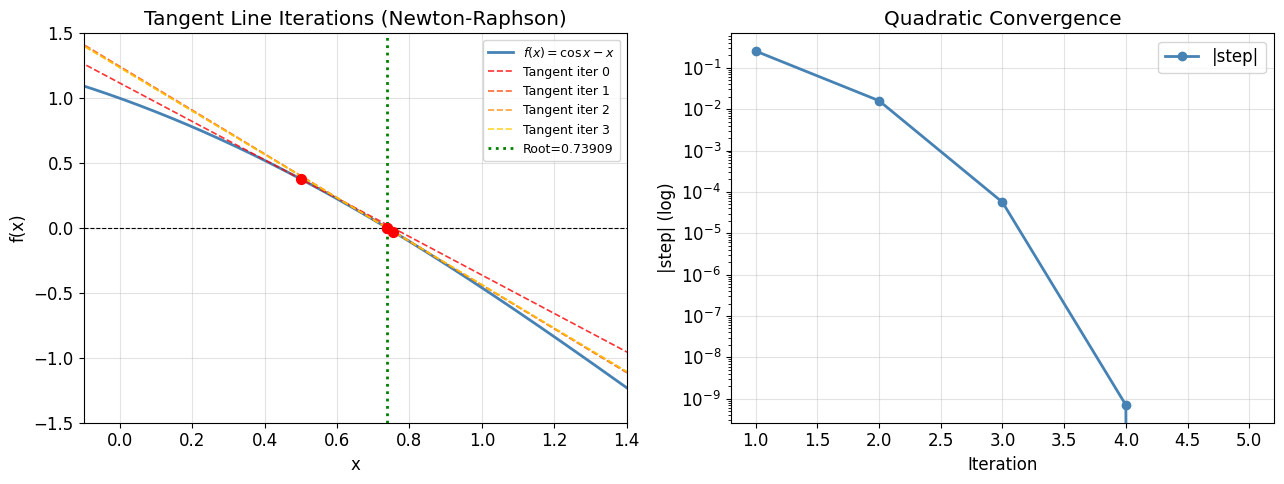

In [4]:
f4  = lambda x: np.cos(x) - x
df4 = lambda x: -np.sin(x) - 1
r_exact = 0.7390851332151607

root4, h4 = newton_raphson(f4, df4, x0=0.5, tol=1e-14, verbose=True)
print(f'\nRoot found : {root4:.14f}')
print(f'Exact      : {r_exact:.14f}')
print(f'Error      : {abs(root4 - r_exact):.2e}')
print(f'Iterations : {len(h4["errors"])}')

# --- Plot: tangent lines ---
x_range = np.linspace(-0.2, 1.5, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_range, f4(x_range), color='steelblue', label=r'$f(x)=\cos x - x$')
ax.axhline(0, color='k', lw=0.8, ls='--')
colors_t = plt.cm.autumn(np.linspace(0, 0.8, min(4, len(h4['iterates'])-1)))
for k in range(min(4, len(h4['iterates'])-1)):
    xk = h4['iterates'][k]
    tang = f4(xk) + df4(xk) * (x_range - xk)
    ax.plot(x_range, tang, color=colors_t[k], lw=1.2, ls='--', alpha=0.8,
            label=f'Tangent iter {k}')
ax.scatter([h4['iterates'][k] for k in range(min(4, len(h4['iterates'])-1))],
           [f4(h4['iterates'][k]) for k in range(min(4, len(h4['iterates'])-1))],
           color='red', s=50, zorder=5)
ax.axvline(root4, color='green', ls=':', lw=2, label=f'Root={root4:.5f}')
ax.set(xlim=(-0.1, 1.4), ylim=(-1.5, 1.5), xlabel='x', ylabel='f(x)',
       title='Tangent Line Iterations (Newton-Raphson)')
ax.legend(fontsize=9)

ax = axes[1]
errs = h4['errors']
ax.semilogy(range(1, len(errs)+1), errs, 'o-', color='steelblue', ms=6, label='|step|')
ax.set(xlabel='Iteration', ylabel='|step| (log)', title='Quadratic Convergence')
ax.legend()

plt.tight_layout()
plt.show()

### 2.2 Chemistry Application - Van der Waals Equation of State

**Background:** The van der Waals equation corrects ideal-gas behaviour:

$$\left(P + \frac{a}{V^2}\right)(V - b) = RT$$

Expanding into a **cubic polynomial** in $V$:

$$f(V) = PV^3 - (Pb + RT)V^2 + aV - ab = 0$$

$$f'(V) = 3PV^2 - 2(Pb + RT)V + a$$

For supercritical conditions there is one real root, found efficiently with Newton-Raphson.

**Case study:** Carbon dioxide (CO2) at $T = 350$ K, $P = 80$ atm.

| Parameter | Value | Units |
|-----------|-------|-------|
| $a$ (CO2) | 3.592 | L2·atm/mol2 |
| $b$ (CO2) | 0.04267 | L/mol |
| $R$ | 0.082057 | L·atm/(mol·K) |

Initial guess: ideal-gas molar volume $V_0 = RT/P$.


Ideal-gas starting guess V0 = 0.35900 L/mol
   n                 x_n          f(x_n)        |step|
--------------------------------------------------------
   1      0.298194287067      1.8176e-01    6.0805e-02
   2      0.266685465946      3.6647e-02    3.1509e-02
   3      0.256280265905      3.3605e-03    1.0405e-02
   4      0.255115334624      3.9736e-05    1.1649e-03
   5      0.255101226976      5.7903e-09    1.4108e-05
   6      0.255101224919      2.2204e-16    2.0564e-09
   7      0.255101224919     -2.2204e-16    5.5511e-17

Molar volume  V  = 0.25510122 L/mol
Compressibility Z = 0.710590  (1.0 = ideal gas)
Iterations        = 7


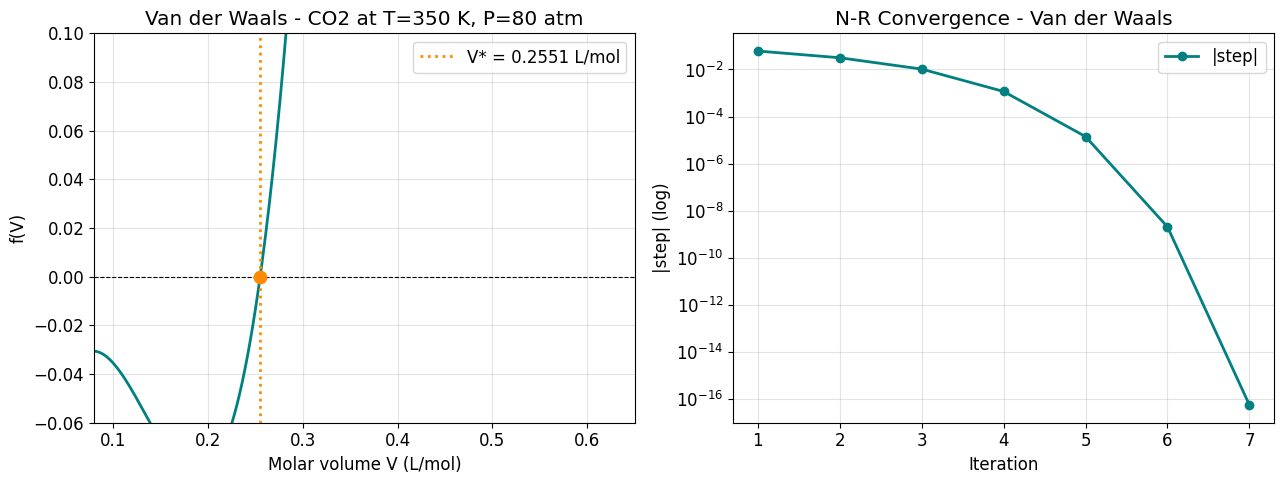

In [5]:
R_gas = 0.082057   # L*atm/(mol*K)
a_co2 = 3.592      # L^2*atm/mol^2
b_co2 = 0.04267    # L/mol
T_co2 = 350.0      # K
P_co2 = 80.0       # atm

V0 = R_gas * T_co2 / P_co2
print(f'Ideal-gas starting guess V0 = {V0:.5f} L/mol')

def f_vdw(V):
    return P_co2*V**3 - (P_co2*b_co2 + R_gas*T_co2)*V**2 + a_co2*V - a_co2*b_co2

def df_vdw(V):
    return 3*P_co2*V**2 - 2*(P_co2*b_co2 + R_gas*T_co2)*V + a_co2

root_vdw, h_vdw = newton_raphson(f_vdw, df_vdw, x0=V0, tol=1e-12, verbose=True)

Z = P_co2 * root_vdw / (R_gas * T_co2)   # compressibility factor
print(f'\nMolar volume  V  = {root_vdw:.8f} L/mol')
print(f'Compressibility Z = {Z:.6f}  (1.0 = ideal gas)')
print(f'Iterations        = {len(h_vdw["errors"])}')

# --- Plots ---
V_range = np.linspace(0.08, 0.65, 600)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(V_range, f_vdw(V_range), color='teal')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(root_vdw, color='darkorange', ls=':', lw=2,
           label=f'V* = {root_vdw:.4f} L/mol')
ax.scatter([root_vdw], [0], color='darkorange', s=80, zorder=5)
ax.set(xlabel='Molar volume V (L/mol)', ylabel='f(V)',
       title='Van der Waals - CO2 at T=350 K, P=80 atm',
       xlim=(0.08, 0.65), ylim=(-0.06, 0.10))
ax.legend()

ax = axes[1]
ax.semilogy(range(1, len(h_vdw['errors'])+1), h_vdw['errors'],
            'o-', color='teal', ms=6, label='|step|')
ax.set(xlabel='Iteration', ylabel='|step| (log)',
       title='N-R Convergence - Van der Waals')
ax.legend()

plt.tight_layout()
plt.show()

### 2.3 Telecommunications Application - Minimum Eb/N0 for Target BER (BPSK)

**Background:** For **Binary Phase-Shift Keying (BPSK)** over an AWGN channel:

$$\text{BER} = \frac{1}{2}\,\text{erfc}\!\left(\sqrt{\frac{E_b}{N_0}}\right)$$

**Problem:** Find the minimum $x = E_b/N_0$ (linear) for target $\text{BER}_0 = 10^{-6}$:

$$f(x) = \frac{1}{2}\,\text{erfc}(\sqrt{x}) - \text{BER}_0 = 0$$

**Derivative** (using $\tfrac{d}{dx}\text{erfc}(\sqrt{x}) = -e^{-x}/\sqrt{\pi x}$):

$$f'(x) = -\frac{e^{-x}}{2\sqrt{\pi x}}$$

This is a **transcendental** equation - no closed-form inverse for erfc.
Expected answer: $E_b/N_0 \approx 10.54$ dB.


Initial guess x0 = 11.2975  (10.53 dB)
   n                 x_n          f(x_n)        |step|
--------------------------------------------------------
   1     11.297521329854      2.1176e-22    2.5700e-11
   2     11.297521329854      2.1176e-22    0.0000e+00

Eb/N0 (linear) = 11.29752133
Eb/N0 (dB)     = 10.5298 dB
Achieved BER   = 1.0000e-06  (target 1.0e-06)
Iterations     = 2


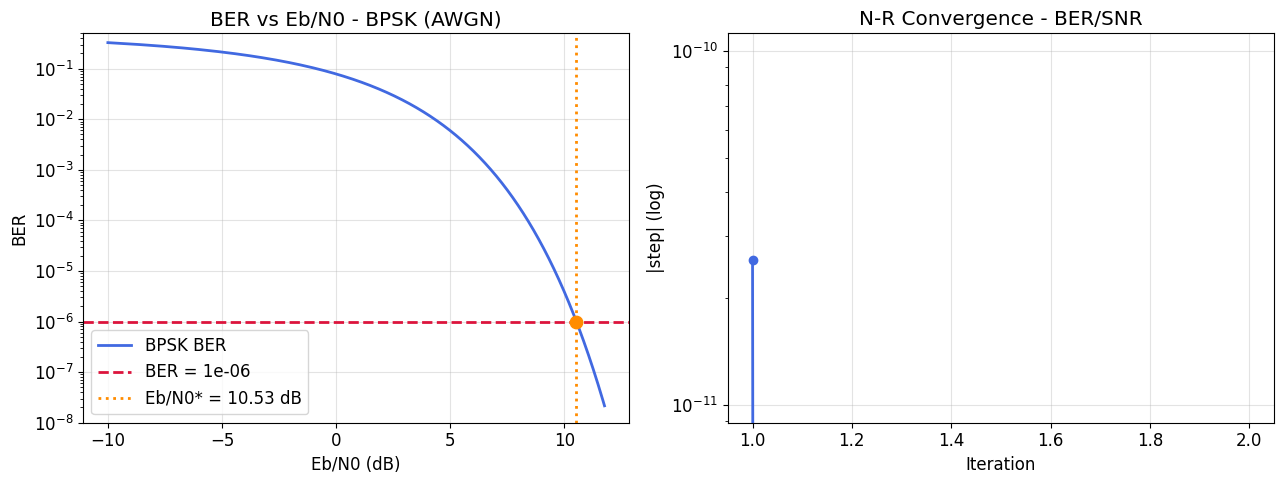

In [6]:
BER_target = 1e-6

f_ber  = lambda x: 0.5 * erfc(np.sqrt(x)) - BER_target
df_ber = lambda x: -np.exp(-x) / (2.0 * np.sqrt(np.pi * x))

# Initial guess via inverse erfc: erfc(y) = 2*BER -> y = erfinv(1 - 2*BER)
y0 = erfinv(1.0 - 2.0 * BER_target)
x0_ber = y0**2
print(f'Initial guess x0 = {x0_ber:.4f}  ({10*np.log10(x0_ber):.2f} dB)')

root_ber, h_ber = newton_raphson(f_ber, df_ber, x0=x0_ber, tol=1e-13, verbose=True)

print(f'\nEb/N0 (linear) = {root_ber:.8f}')
print(f'Eb/N0 (dB)     = {10*np.log10(root_ber):.4f} dB')
print(f'Achieved BER   = {0.5*erfc(np.sqrt(root_ber)):.4e}  (target {BER_target:.1e})')
print(f'Iterations     = {len(h_ber["errors"])}')

# --- Plots ---
x_vals = np.linspace(0.1, 15, 800)
ber_vals = 0.5 * erfc(np.sqrt(x_vals))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(10*np.log10(x_vals), ber_vals, color='royalblue', label='BPSK BER')
ax.axhline(BER_target, color='crimson', ls='--', label=f'BER = {BER_target:.0e}')
ax.axvline(10*np.log10(root_ber), color='darkorange', ls=':', lw=2,
           label=f'Eb/N0* = {10*np.log10(root_ber):.2f} dB')
ax.scatter([10*np.log10(root_ber)], [BER_target], color='darkorange', s=80, zorder=5)
ax.set(xlabel='Eb/N0 (dB)', ylabel='BER', ylim=(1e-8, 0.5),
       title='BER vs Eb/N0 - BPSK (AWGN)')
ax.legend()

ax = axes[1]
ax.semilogy(range(1, len(h_ber['errors'])+1), h_ber['errors'],
            'o-', color='royalblue', ms=6)
ax.set(xlabel='Iteration', ylabel='|step| (log)',
       title='N-R Convergence - BER/SNR')

plt.tight_layout()
plt.show()

---
## 3. Head-to-Head Comparison: Newton-Raphson vs. Bisection

Both methods applied to $f(x) = \cos x - x$ with the same effective starting information:
- Bisection: bracket $[0, 1]$
- Newton-Raphson: midpoint $x_0 = 0.5$


Bisection iterations     : 47
Newton-Raphson iterations: 5
Speed-up factor          : 9.4x


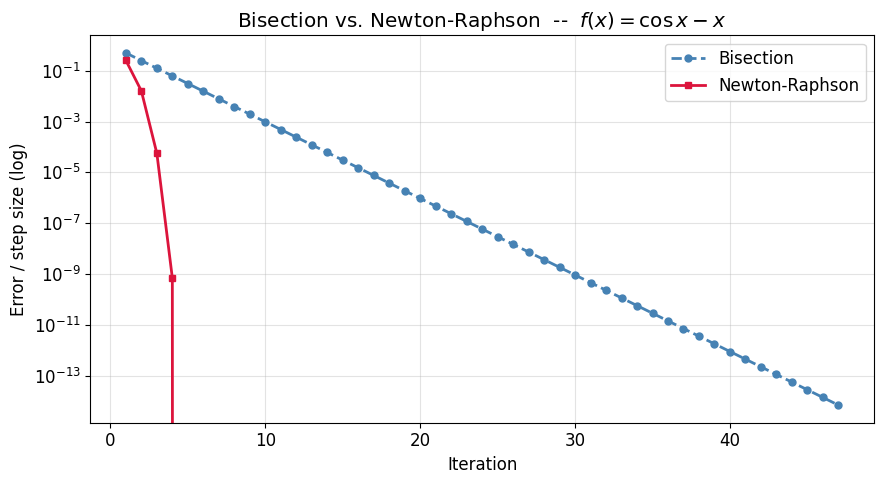

In [7]:
# Local copy of bisection (normally imported from 01_Bisection.ipynb)
def bisection_local(f, a, b, tol=1e-14, max_iter=60):
    if f(a)*f(b) >= 0: raise ValueError('IVT not satisfied')
    errs = []
    c = a
    for _ in range(max_iter):
        c = (a + b) / 2.0
        errs.append((b - a) / 2.0)
        if (b - a)/2.0 < tol or f(c) == 0.0: break
        if f(a)*f(c) < 0: b = c
        else: a = c
    return c, errs

_, errs_bis = bisection_local(f4, 0.0, 1.0, tol=1e-14)
_, h_nr_cmp = newton_raphson(f4, df4, x0=0.5, tol=1e-14)
errs_nr = h_nr_cmp['errors']

print(f'Bisection iterations     : {len(errs_bis)}')
print(f'Newton-Raphson iterations: {len(errs_nr)}')
print(f'Speed-up factor          : {len(errs_bis)/len(errs_nr):.1f}x')

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(range(1, len(errs_bis)+1), errs_bis, 'o--',
            color='steelblue', ms=5, label='Bisection')
ax.semilogy(range(1, len(errs_nr)+1), errs_nr, 's-',
            color='crimson', ms=5, label='Newton-Raphson')
ax.set(xlabel='Iteration', ylabel='Error / step size (log)',
       title=r'Bisection vs. Newton-Raphson  --  $f(x)=\cos x - x$')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Student Exercises

---

**Exercise 1 - Classic transcendental equation**
Find all roots of $g(x) = x - \tan x$ in the interval $(3\pi/2,\; 5\pi/2)$ using Newton-Raphson.
$g'(x) = 1 - \sec^2 x$. Plot first to choose a good $x_0$.

---

**Exercise 2 - Chemical kinetics: Arrhenius equation**
For a reaction: $k_1 = 0.050\,\text{s}^{-1}$ at $T_1=300$ K, $k_2 = 0.500\,\text{s}^{-1}$ at $T_2=350$ K.
Find the activation energy $E_a$ (kJ/mol) by solving the Arrhenius ratio equation with Newton-Raphson.
Verify analytically using $\ln(k_2/k_1) = (E_a/R)(1/T_1 - 1/T_2)$.

---

**Exercise 3 - Dispersion-zero wavelength in optical fibre**
Using the Sellmeier model for fused silica with coefficients
$B_1=0.6961663$, $B_2=0.4079426$, $B_3=0.8974794$,
$C_1=0.0684043^2$, $C_2=0.1162414^2$, $C_3=9.896161^2$ (wavelength in micrometres):

$$n^2(\lambda) = 1 + \sum_{i=1}^{3}\frac{B_i \lambda^2}{\lambda^2 - C_i}$$

Find the zero-dispersion wavelength $\lambda_0$ (where $d^2n/d\lambda^2 = 0$) using Newton-Raphson.
Expected: $\lambda_0 \approx 1.27\,\mu\text{m}$.

---

**Exercise 4 - Failure modes**
a) Apply Newton-Raphson to $f(x) = x^{1/3}$ from $x_0=0.1$. What happens? Why?
b) Apply it to $f(x) = x^2 - 1$ from $x_0 = 0$. Explain the failure and propose a bounded-step fix.

---

**Exercise 5 - Secant Method**
The Secant Method avoids the explicit derivative:
$$x_{n+1} = x_n - f(x_n)\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$
Its convergence order is $p \approx 1.618$ (golden ratio).
a) Implement the Secant Method.
b) Verify its convergence order on $f(x) = \cos x - x$ and compare with Newton-Raphson.


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers* (7th ed., pp. 126-145).
   McGraw-Hill Education.
   *Primary textbook. Section 5.3 derives the Newton-Raphson update; Section 5.4 discusses pitfalls
   (zero derivative, divergence, cycling) directly related to Exercise 4.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis* (10th ed., pp. 67-80).
   Cengage Learning.
   *Theorem 2.6 contains the rigorous quadratic convergence proof reproduced in Section 1.2.
   Exercise 2.17 covers the optical-fibre dispersion application (Exercise 3).*

3. **Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P.** (2007).
   *Numerical Recipes: The Art of Scientific Computing* (3rd ed., Sections 9.4-9.6).
   Cambridge University Press.
   *Practical safeguards against divergence - bracketed Newton-Raphson and line-search strategies
   for the failure cases in Exercise 4.*

4. **Prausnitz, J. M., Lichtenthaler, R. N., & de Azevedo, E. G.** (1999).
   *Molecular Thermodynamics of Fluid-Phase Equilibria* (3rd ed., pp. 30-42). Prentice Hall.
   *Source for van der Waals parameters for CO2 and the thermodynamic context of Example 2.2.
   Appendix A lists parameters for common gases.*

5. **Proakis, J. G., & Salehi, M.** (2008). *Digital Communications* (5th ed., pp. 257-268).
   McGraw-Hill.
   *Derivation of the BPSK BER formula used in Example 2.3. Section 4.3 covers AWGN performance
   bounds and the erfc representation of BER for M-ary PSK modulations.*
